# Syntropic Agroforestry XGBoost Optimizer - Full Training and Analysis Notebook

This notebook now runs the complete optimizer workflow in order: validate species data, train the XGBoost scorer, generate the optimal field plan, and then analyse the saved outputs.


## Before you run it
- Install the core dependencies once: `pip install xgboost pandas numpy tqdm`
- Install notebook / plotting extras if needed: `pip install matplotlib jupyter`
- No PyTorch is required; the scorer is XGBoost, not a CNN.

> **Input data:** `data/Fixed_dataset.csv`  
> **Model:** `models/calorie_scoring_model.json` + `calorie_scoring_model.meta.json`  
> **Outputs:** `output/plan_result.json`, `output/grid_visualization.npy`

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json
from pathlib import Path
import sys

# Add the optimizer root to path so imports work from the notebook folder
notebook_dir = Path.cwd().resolve()
candidate_roots = [
    notebook_dir,
    notebook_dir.parent,
    notebook_dir.parent.parent,
    notebook_dir / 'optimizer',
    notebook_dir.parent / 'optimizer',
    notebook_dir.parent.parent / 'optimizer',
]
optimizer_root = None
for candidate in candidate_roots:
    if (candidate / 'data_loader.py').exists():
        optimizer_root = candidate
        sys.path.insert(0, str(candidate))
        break
if optimizer_root is None:
    raise FileNotFoundError('Could not locate optimizer root containing data_loader.py')

from data_loader import SpeciesDataValidator

## 1. Validate Species Data
This notebook now runs the full pipeline in order: validate the dataset, train the scorer, optimise a field plan, and then inspect the generated outputs.

In [2]:
from data_loader import SpeciesDataValidator

print('Validating species data...')
validator = SpeciesDataValidator(r'C:\Users\rasmu\FoodPlan Project\FarmPlan-Test-Data\optimizer\data\Fixed_dataset.csv')
validator.load().validate()
validator.print_report()

species_df = validator.df.copy()
all_species = sorted(species_df[species_df['calories_min'].notna()]['ID'].unique().tolist())
print(f'\nSpecies with complete calorie data: {len(all_species)}')

INFO:data_loader:Loaded 110 rows from Fixed_dataset.csv


Validating species data...

SPECIES DATA VALIDATION REPORT

Total species: 110

By Category:
  Tree: 38
  Shrub: 31
  Perennial: 41

By Strata:
  Emergent canopy: 9
  High canopy: 10
  Medium tree: 8
  Low/medium tree: 8
  Medium/High tree: 2
  Low tree: 1
  Shrub layer: 31
  Climber/liana: 6
  Tall herb geophyte: 2
  Herb geophyte: 3
  Tall herb: 9
  Herb: 13
  Groundcover: 4
  Tall emergent wetland: 1
  Herb aquatic: 1
  Wetland herb geophyte: 1
  Aquatic rhizome: 1

Data Quality:
  ID: 110/110 (100.0%)
  Category: 110/110 (100.0%)
  Strata: 110/110 (100.0%)
  German name: 110/110 (100.0%)
  spacing_m: 106/110 (96.4%)
  calories_numeric: 110/110 (100.0%)
  spacing_numeric: 106/110 (96.4%)

Issues:
  [!] Missing spacing_m: 4 rows


Species with complete calorie data: 110


C:\Users\rasmu\FoodPlan Project\FarmPlan-Test-Data\optimizer\data_loader.py:150: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.df["Strata"] = self.df.apply(_first_active, axis=1)
C:\Users\rasmu\FoodPlan Project\FarmPlan-Test-Data\optimizer\data_loader.py:158: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.df["calories_min"] = pd.to_numeric(
C:\Users\rasmu\FoodPlan Project\FarmPlan-Test-Data\optimizer\data_loader.py:175: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.ins

## 2. Train the XGBoost Scorer
This step generates training and validation plans from the classical sampler, fits the model, and saves the scorer artifacts into `models/`.

In [3]:
from train import main as train_main

print('Training the XGBoost calorie scorer...')
model, all_species, metrics_out = train_main(n_train=500, n_val=100)
print('Training complete. Generated models/calorie_scoring_model.json, models/calorie_scoring_model.meta.json, and models/metrics.json.')

INFO:train:Loading species data …
INFO:data_loader:Loaded 110 rows from Fixed_dataset.csv
C:\Users\rasmu\FoodPlan Project\FarmPlan-Test-Data\optimizer\data_loader.py:150: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.df["Strata"] = self.df.apply(_first_active, axis=1)
C:\Users\rasmu\FoodPlan Project\FarmPlan-Test-Data\optimizer\data_loader.py:158: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.df["calories_min"] = pd.to_numeric(
C:\Users\rasmu\FoodPlan Project\FarmPlan-Test-Data\optimizer\data_loader.py:175: Performance

Training the XGBoost calorie scorer...


Generating plans: 100%|██████████| 500/500 [44:11<00:00,  5.30s/it]
INFO:train:Generating 100 validation plans …
Generating plans: 100%|██████████| 100/100 [06:24<00:00,  3.85s/it]
INFO:train:Calorie range  train: 367,918 – 2,021,714 kcal  |  val: 426,675 – 1,731,812 kcal
INFO:train:Training XGBoost scorer …
INFO:train:Train  MAE=5,581  RMSE=7,334  MAPE=0.77%
INFO:train:Val    MAE=48,911  RMSE=61,650  MAPE=6.01%
INFO:train:Saved model + metrics to models/


Training complete. Generated models/calorie_scoring_model.json, models/calorie_scoring_model.meta.json, and models/metrics.json.


## 3. Run End-to-End Optimization
This step loads the trained XGBoost scorer and writes the plan outputs that the analysis cells below will inspect.

In [4]:
from end_to_end import main as optimize_main

print('Running end-to-end field optimization...')
optimize_main()
print('Optimization complete. Generated output/plan_result.json, output/plan_placements.json, and output/grid_visualization.npy.')

INFO:end_to_end:Loading species data ...
INFO:data_loader:Loaded 110 rows from Fixed_dataset.csv
C:\Users\rasmu\FoodPlan Project\FarmPlan-Test-Data\optimizer\data_loader.py:150: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.df["Strata"] = self.df.apply(_first_active, axis=1)
C:\Users\rasmu\FoodPlan Project\FarmPlan-Test-Data\optimizer\data_loader.py:158: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.df["calories_min"] = pd.to_numeric(
C:\Users\rasmu\FoodPlan Project\FarmPlan-Test-Data\optimizer\data_loader.py:175: Perf

Running end-to-end field optimization...


INFO:constraint_sampler:Initialized grid 120 x 80 (9600 cells) for 60.0m x 40.0m field with polygon mask (7 pts)
INFO:constraint_sampler:Initialized grid 120 x 80 (9600 cells) for 60.0m x 40.0m field with polygon mask (7 pts)
INFO:constraint_sampler:Initialized grid 120 x 80 (9600 cells) for 60.0m x 40.0m field with polygon mask (7 pts)
INFO:constraint_sampler:Initialized grid 120 x 80 (9600 cells) for 60.0m x 40.0m field with polygon mask (7 pts)
INFO:constraint_sampler:Initialized grid 120 x 80 (9600 cells) for 60.0m x 40.0m field with polygon mask (7 pts)
INFO:constraint_sampler:Initialized grid 120 x 80 (9600 cells) for 60.0m x 40.0m field with polygon mask (7 pts)
INFO:constraint_sampler:Initialized grid 120 x 80 (9600 cells) for 60.0m x 40.0m field with polygon mask (7 pts)
INFO:constraint_sampler:Initialized grid 120 x 80 (9600 cells) for 60.0m x 40.0m field with polygon mask (7 pts)
INFO:constraint_sampler:Initialized grid 120 x 80 (9600 cells) for 60.0m x 40.0m field with poly


OPTIMAL FIELD PLAN  —  0.24 ha (60 m × 40 m)
Field grid:         120 x 80 cells (50 cm each)
Total placements:   52
Unique species:     31

Exact calories:        1,715,616 kcal / year
Spacing check:      ✓ PASS

Breakdown by strata:
  Aquatic rhizome                1 plants  1 species
  Climber/liana                  4 plants  2 species
  Emergent canopy                7 plants  3 species
  Groundcover                    3 plants  3 species
  Herb                           1 plants  1 species
  Herb aquatic                   2 plants  1 species
  Herb geophyte                  2 plants  2 species
  High canopy                    4 plants  3 species
  Low tree                       1 plants  1 species
  Low/medium tree                9 plants  3 species
  Medium tree                    7 plants  3 species
  Medium/High tree               3 plants  2 species
  Shrub layer                    5 plants  3 species
  Tall herb                      1 plants  1 species
  Tall herb geophyte   

## 4. Load Training Metrics

In [5]:
with open(optimizer_root / 'models' / 'metrics.json', 'r') as f:
    metrics = json.load(f)

print("Training Metrics:")
print(f"  Train MAE: {metrics['train']['mae']:,.0f} kcal")
print(f"  Train RMSE: {metrics['train']['rmse']:,.0f} kcal")
print(f"  Train MAPE: {metrics['train']['mape']:.2f}%")
print()
print("Validation Metrics:")
print(f"  Val MAE: {metrics['val']['mae']:,.0f} kcal")
print(f"  Val RMSE: {metrics['val']['rmse']:,.0f} kcal")
print(f"  Val MAPE: {metrics['val']['mape']:.2f}%")

Training Metrics:
  Train MAE: 5,581 kcal
  Train RMSE: 7,334 kcal
  Train MAPE: 0.77%

Validation Metrics:
  Val MAE: 48,911 kcal
  Val RMSE: 61,650 kcal
  Val MAPE: 6.01%


## 5. Load Optimal Plan Result

In [6]:
with open(optimizer_root / 'output' / 'plan_result.json', 'r') as f:
    plan = json.load(f)

print("Optimal Plan Summary:")
print(f"  Exact calories:     {plan['exact_calories']:,.0f} kcal")
# BUG FIX: key was 'nn_predicted_calories'; end_to_end.py writes 'predicted_calories'
print(f"  XGBoost predicted:  {plan['predicted_calories']:,.0f} kcal")
print(f"  Prediction error:   {plan['error_pct']:.2f}%")
print(f"  Total placements:   {plan['placements']}")
print(f"  Unique species:     {plan['species_count']}")


Optimal Plan Summary:
  Exact calories:     1,715,616 kcal
  XGBoost predicted:  1,715,616 kcal
  Prediction error:   0.00%
  Total placements:   52
  Unique species:     31


## 6. Visualize Grid Plan

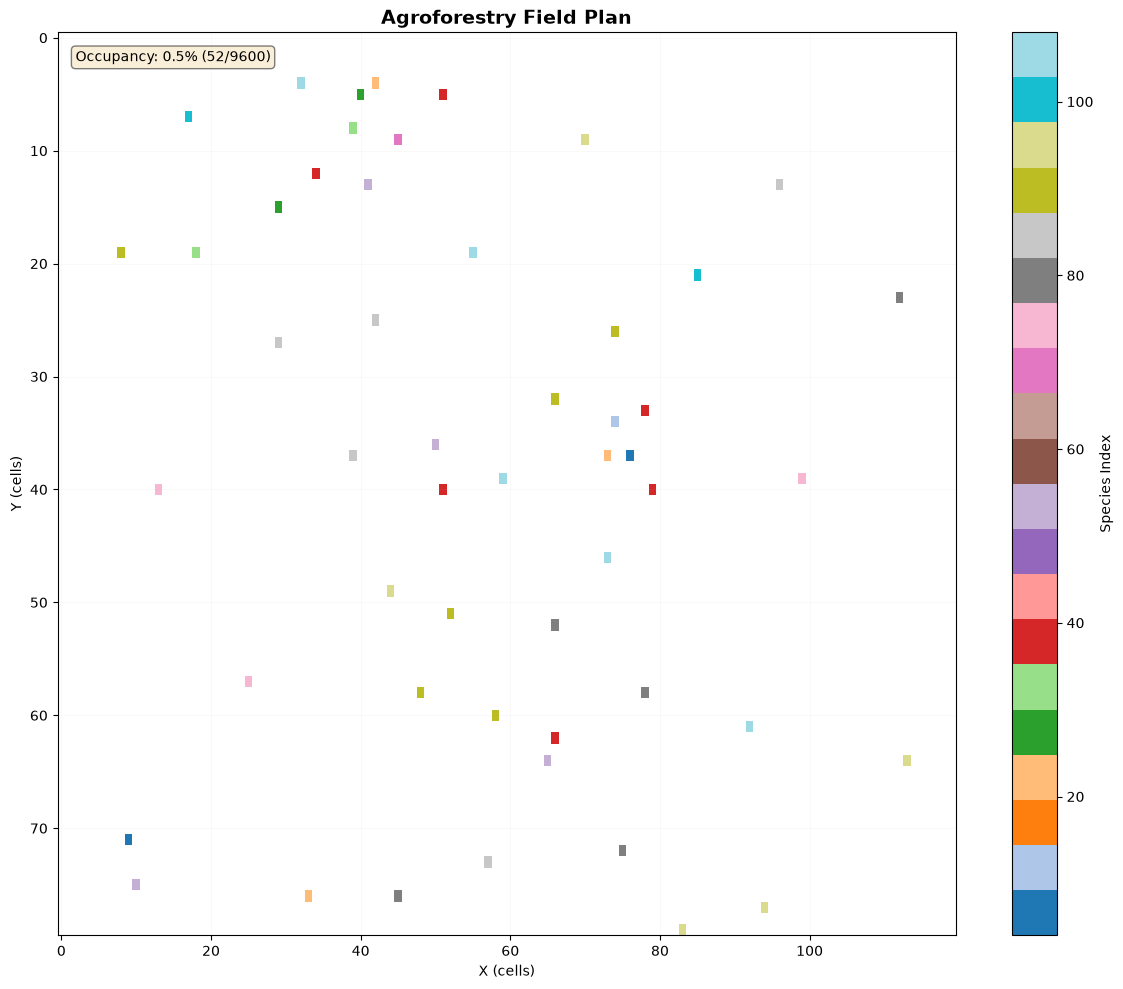

Grid shape: (80, 120)
Occupied cells: 52 / 9600 (0.5%)


In [7]:
# Load grid visualization
grid = np.load(optimizer_root / 'output' / 'grid_visualization.npy')

fig, ax = plt.subplots(1, 1, figsize=(12, 10))

# Create a visualization where empty cells are -1 (white), others get color
display_grid = grid.astype(float).copy()
display_grid[display_grid == -1] = np.nan  # Show empty cells as white

im = ax.imshow(display_grid, cmap='tab20', aspect='auto', origin='upper')
ax.set_title('Agroforestry Field Plan', fontsize=14, fontweight='bold')
ax.set_xlabel('X (cells)')
ax.set_ylabel('Y (cells)')

# Add grid
ax.grid(True, alpha=0.1, linewidth=0.5)

cbar = plt.colorbar(im, ax=ax, label='Species Index')

# Add statistics
occupied = np.sum(grid >= 0)
total = grid.size
occupancy = 100 * occupied / total
ax.text(0.02, 0.98, f'Occupancy: {occupancy:.1f}% ({occupied}/{total})',
        transform=ax.transAxes, fontsize=10, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig(optimizer_root / 'output' / 'plan_visualization.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Grid shape: {grid.shape}")
print(f"Occupied cells: {occupied} / {total} ({occupancy:.1f}%)")

## 7. Species Data Overview

INFO:data_loader:Loaded 110 rows from Fixed_dataset.csv
C:\Users\rasmu\FoodPlan Project\FarmPlan-Test-Data\optimizer\data_loader.py:150: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.df["Strata"] = self.df.apply(_first_active, axis=1)
C:\Users\rasmu\FoodPlan Project\FarmPlan-Test-Data\optimizer\data_loader.py:158: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.df["calories_min"] = pd.to_numeric(
C:\Users\rasmu\FoodPlan Project\FarmPlan-Test-Data\optimizer\data_loader.py:175: PerformanceWarning: DataFrame is highly fragm

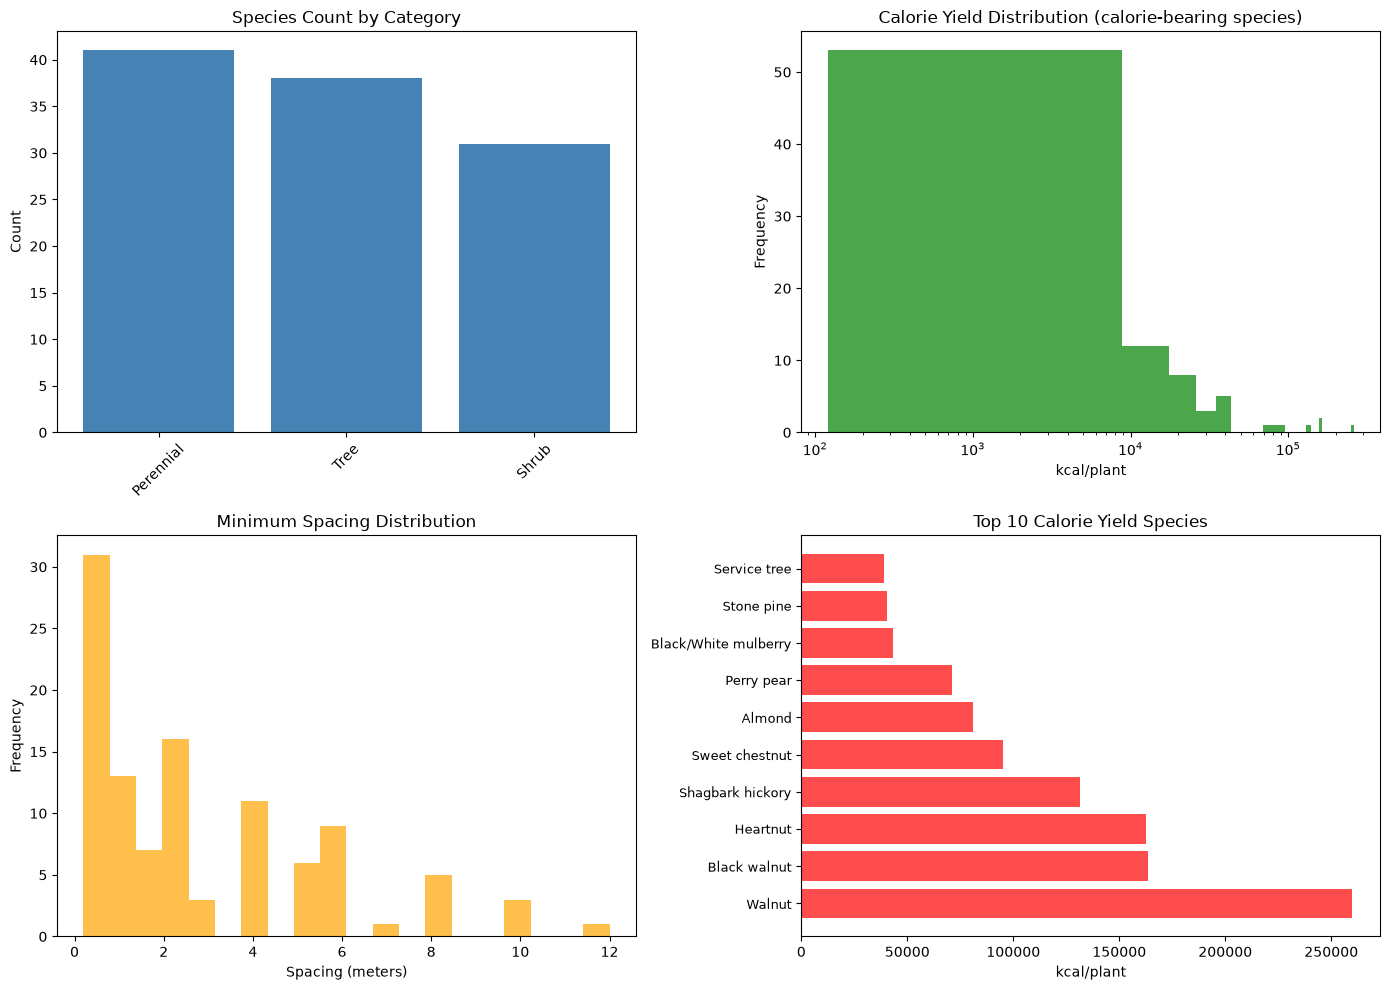

In [8]:
# BUG FIX: use Fixed_dataset.csv (pre-parsed Strata/calories_min/spacing_m)
# Passing no argument uses SpeciesDataValidator.DEFAULT_CSV automatically.
validator = SpeciesDataValidator(r'C:\Users\rasmu\FoodPlan Project\FarmPlan-Test-Data\optimizer\data\Fixed_dataset.csv')
validator.load().validate()

# Summary statistics
df = validator.df
df_complete = df[df['calories_min'].notna()]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Species by category
category_counts = df_complete['Category'].value_counts()
axes[0, 0].bar(category_counts.index, category_counts.values, color='steelblue')
axes[0, 0].set_title('Species Count by Category')
axes[0, 0].set_ylabel('Count')
axes[0, 0].tick_params(axis='x', rotation=45)

# Plot 2: Calorie distribution
# BUG FIX: calories_min contains 0 values (non-calorie species like oaks/N-fixers).
# Filter to > 0 before log-scale histogram to avoid log(0) warnings.
cal_nonzero = df_complete[df_complete['calories_min'] > 0]['calories_min']
axes[0, 1].hist(cal_nonzero, bins=30, color='green', alpha=0.7)
axes[0, 1].set_title('Calorie Yield Distribution (calorie-bearing species)')
axes[0, 1].set_xlabel('kcal/plant')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_xscale('log')

# Plot 3: Spacing distribution
axes[1, 0].hist(df_complete['spacing_m'], bins=20, color='orange', alpha=0.7)
axes[1, 0].set_title('Minimum Spacing Distribution')
axes[1, 0].set_xlabel('Spacing (meters)')
axes[1, 0].set_ylabel('Frequency')

# Plot 4: Top 10 highest calorie species
top_species = df_complete.nlargest(10, 'calories_min')
axes[1, 1].barh(range(len(top_species)), top_species['calories_min'].values,
                color='red', alpha=0.7)
axes[1, 1].set_yticks(range(len(top_species)))
axes[1, 1].set_yticklabels(
    [f"{row['English name'][:20]}" for _, row in top_species.iterrows()], fontsize=9
)
axes[1, 1].set_title('Top 10 Calorie Yield Species')
axes[1, 1].set_xlabel('kcal/plant')

plt.tight_layout()
plt.savefig(optimizer_root / 'output' / 'species_analysis.png', dpi=150, bbox_inches='tight')
plt.show()


## 8. Model Performance Summary

In [9]:
# Print comprehensive metrics
print("MODEL PERFORMANCE SUMMARY")
print("=" * 60)
print(f"\nTraining Configuration:")
print(f"  Model:         {metrics['model_config']['type']}")
# BUG FIX: 'n_channels'/'hidden_dim' were CNN keys; XGBoost metrics has
# 'feature_count' and 'n_species' instead.
print(f"  Features:      {metrics['model_config']['feature_count']}")
print(f"  Species:       {metrics['model_config']['n_species']}")
print(f"  Train samples: {metrics['model_config']['n_train_samples']}")
print(f"  Val samples:   {metrics['model_config']['n_val_samples']}")

print(f"\nTraining Metrics:")
print(f"  MAE:  {metrics['train']['mae']:>12,.0f} kcal")
print(f"  RMSE: {metrics['train']['rmse']:>12,.0f} kcal")
print(f"  MAPE: {metrics['train']['mape']:>12.2f}%")

print(f"\nValidation Metrics:")
print(f"  MAE:  {metrics['val']['mae']:>12,.0f} kcal")
print(f"  RMSE: {metrics['val']['rmse']:>12,.0f} kcal")
print(f"  MAPE: {metrics['val']['mape']:>12.2f}%")

print(f"\nOptimal Plan:")
print(f"  Exact calories:    {plan['exact_calories']:>12,.0f} kcal")
# BUG FIX: key was 'nn_predicted_calories'; end_to_end.py writes 'predicted_calories'
print(f"  XGBoost predicted: {plan['predicted_calories']:>12,.0f} kcal")
print(f"  Prediction error:  {plan['error_pct']:>12.2f}%")
print(f"  Total placements:  {plan['placements']:>12}")
print(f"  Unique species:    {plan['species_count']:>12}")
print("\n" + "=" * 60)


MODEL PERFORMANCE SUMMARY

Training Configuration:
  Model:         XGBRegressor
  Features:      114
  Species:       110
  Train samples: 500
  Val samples:   100

Training Metrics:
  MAE:         5,581 kcal
  RMSE:        7,334 kcal
  MAPE:         0.77%

Validation Metrics:
  MAE:        48,911 kcal
  RMSE:       61,650 kcal
  MAPE:         6.01%

Optimal Plan:
  Exact calories:       1,715,616 kcal
  XGBoost predicted:    1,715,616 kcal
  Prediction error:          0.00%
  Total placements:            52
  Unique species:              31

